# Simulation Fidelity Assessment

Statistical comparison of real vs. simulated data for two simulation studies:

1. **Single-omics (proteomics)** — MERS-CoV source / SARS-CoV-2 target, using `generate_synth_data_multiomics_latent` with a single proteomics layer.
2. **Multi-omics** — mouse influenza source / mouse MERS-CoV target, across all four omic layers (proteomics, metabolomics, positive-mode lipidomics, negative-mode lipidomics).

Because synthetic features are PCA-derived linear combinations rather than copies of individual features, comparisons are made at the **distributional level** — no feature-to-feature pairing is assumed. KS tests compare the distribution of per-feature statistics (mean, variance, skewness, excess kurtosis) and pairwise correlations (within-omic and cross-omic) between real and synthetic data.

**Fidelity vs. simulation parameters:** The simulation study uses K=10 shared factors and Gaussian latent sampling. This fidelity assessment uses K=30 and empirical (KDE) latent sampling to characterise the generator's maximum fidelity. Both source and target domains are assessed independently — PCA is fit on the domain being tested — so each comparison is a fair test of the generator's ability to reproduce that domain's distributional properties.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, ks_2samp

from omicstl.simulation_utils.data_generation import generate_synth_data_multiomics_latent

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

# All four omic layers used in the multi-omics simulation study
OMICS = ['prot', 'metab', 'lipidpos', 'lipidneg']
COLORS = {
    'prot':     '#1565C0',
    'metab':    '#2E7D32',
    'lipidpos': '#E65100',
    'lipidneg': '#6A1B9A',
}
LABELS = {
    'prot':     'Proteomics',
    'metab':    'Metabolomics',
    'lipidpos': 'Lipidomics (+)',
    'lipidneg': 'Lipidomics (−)',
}
OMIC_PAIRS = [
    ('prot',     'metab'),
    ('prot',     'lipidpos'),
    ('prot',     'lipidneg'),
    ('metab',    'lipidpos'),
    ('metab',    'lipidneg'),
    ('lipidpos', 'lipidneg'),
]

# Real = omic-identifying color; Simulated = consistent neutral gray
SYN_COLOR = '#9E9E9E'

## 1. Load data and generate synthetic counterparts

In [2]:
def load_omic(path):
    df = pd.read_csv(path, index_col=0)
    return df.drop(columns=[c for c in ('response', 'Resp') if c in df.columns])

# ── Single-omics: MERS-CoV (source) / SARS-CoV-2 (target), proteomics ────
single_source = load_omic('data/source_dset.csv')
single_target = load_omic('data/target_dset.csv')
n_src_s = single_source.shape[0]
n_tgt_s = single_target.shape[0]
print(f'Single-omics  — source: {single_source.shape},  target: {single_target.shape}')

# ── Multi-omics: mouse influenza (source) / mouse MERS-CoV (target) ───────
source_omics_raw = {k: load_omic(f'data/source_{k}.csv') for k in OMICS}
target_omics_raw = {k: load_omic(f'data/target_{k}.csv') for k in OMICS}

# Align each domain to the common sample set across all layers
# (lipidpos source has 70 samples vs 71 in the other layers)
common_src = source_omics_raw['prot'].index
for k in OMICS:
    common_src = common_src.intersection(source_omics_raw[k].index)
source_omics = {k: source_omics_raw[k].loc[common_src] for k in OMICS}

common_tgt = target_omics_raw['prot'].index
for k in OMICS:
    common_tgt = common_tgt.intersection(target_omics_raw[k].index)
target_omics = {k: target_omics_raw[k].loc[common_tgt] for k in OMICS}

n_src_m = source_omics['prot'].shape[0]
n_tgt_m = target_omics['prot'].shape[0]

print(f'\nMulti-omics after alignment — source: {n_src_m} samples,  target: {n_tgt_m} samples')
print(f"{'Omic':<16}  {'Src shape':>12}  {'Tgt shape':>12}")
for k in OMICS:
    print(f"{LABELS[k]:<16}  {str(source_omics[k].shape):>12}  {str(target_omics[k].shape):>12}")

# ── Shared generation settings ────────────────────────────────────────────
GEN_KWARGS = dict(
    n_shared_factors=30,
    shared_var_ratio=0.9,
    snr=None,
    random_state=42,
    top_n_per_omic=150,
    latent_distribution="empirical",
)

# ── Single-omics synthetic generation (PCA fit on each domain independently)
syn_src_s, _, _, _ = generate_synth_data_multiomics_latent(
    source_omics={'prot': single_source},
    target_omics={'prot': single_source},
    n_output_samps_source=n_src_s, n_output_samps_target=n_src_s,
    alpha=0.0, **GEN_KWARGS,
)
syn_tgt_s, _, _, _ = generate_synth_data_multiomics_latent(
    source_omics={'prot': single_target},
    target_omics={'prot': single_target},
    n_output_samps_source=n_tgt_s, n_output_samps_target=n_tgt_s,
    alpha=0.0, **GEN_KWARGS,
)

# ── Multi-omics synthetic generation ──────────────────────────────────────
syn_src_m, _, _, _ = generate_synth_data_multiomics_latent(
    source_omics=source_omics, target_omics=source_omics,
    n_output_samps_source=n_src_m, n_output_samps_target=n_src_m,
    alpha=0.0, **GEN_KWARGS,
)
syn_tgt_m, _, _, _ = generate_synth_data_multiomics_latent(
    source_omics=target_omics, target_omics=target_omics,
    n_output_samps_source=n_tgt_m, n_output_samps_target=n_tgt_m,
    alpha=0.0, **GEN_KWARGS,
)

print(f'\nSynthetic shapes:')
print(f"  Single-omics  src: {syn_src_s['prot'].shape},  tgt: {syn_tgt_s['prot'].shape}")
for k in OMICS:
    print(f"  Multi {k:<10} src: {syn_src_m[k].shape},  tgt: {syn_tgt_m[k].shape}")

Single-omics  — source: (358, 475),  target: (240, 475)

Multi-omics after alignment — source: 70 samples,  target: 45 samples
Omic                 Src shape     Tgt shape
Proteomics          (70, 2030)    (45, 1971)
Metabolomics         (70, 163)     (45, 163)
Lipidomics (+)       (70, 249)     (45, 143)
Lipidomics (−)       (70, 152)     (45, 163)

Synthetic shapes:
  Single-omics  src: (358, 150),  tgt: (240, 150)
  Multi prot       src: (70, 150),  tgt: (45, 150)
  Multi metab      src: (70, 150),  tgt: (45, 150)
  Multi lipidpos   src: (70, 150),  tgt: (45, 143)
  Multi lipidneg   src: (70, 150),  tgt: (45, 150)


## 2. Helper functions

In [3]:
def align(real_df: pd.DataFrame, syn_df: pd.DataFrame):
    """Restrict to shared column names; fall back to using all columns of the smaller."""
    common = [c for c in syn_df.columns if c in real_df.columns]
    if common:
        return real_df[common], syn_df[common]
    n = min(real_df.shape[1], syn_df.shape[1])
    return real_df.iloc[:, :n], syn_df.iloc[:, :n]


def feature_stats(df: pd.DataFrame) -> dict:
    v = df.values.astype(float)
    return {
        'Mean':            v.mean(axis=0),
        'Variance':        v.var(axis=0, ddof=1),
        'Skewness':        skew(v, axis=0),
        'Excess kurtosis': kurtosis(v, axis=0, fisher=True),
    }


def upper_tri_corr(df: pd.DataFrame) -> np.ndarray:
    c = np.corrcoef(df.values.astype(float), rowvar=False)
    return c[np.triu_indices(c.shape[0], k=1)]


def cross_corr(df_a: pd.DataFrame, df_b: pd.DataFrame) -> np.ndarray:
    """All pairwise correlations between features in df_a and df_b.
    Trims to the shorter sample count if the two DataFrames have different row counts."""
    n = min(len(df_a), len(df_b))
    a = df_a.iloc[:n].values.astype(float)
    b = df_b.iloc[:n].values.astype(float)
    az = (a - a.mean(0)) / (a.std(0, ddof=1) + 1e-12)
    bz = (b - b.mean(0)) / (b.std(0, ddof=1) + 1e-12)
    return (az.T @ bz / (n - 1)).ravel()


def ks_row(real_v, sim_v, metric, layer):
    d, p = ks_2samp(real_v, sim_v)
    return {'Layer': layer, 'Metric': metric,
            'KS statistic': round(d, 4),
            'p-value': p}


def fmt_p(p):
    return f'{p:.3f}' if p >= 0.001 else f'{p:.2e}'

## 3. KS tests — per-feature means, variances, skewness, kurtosis

In [4]:
feat_rows = []
feat_cache = {}

# ── Single-omics feature stats ─────────────────────────────────────────────
for domain, real_df, syn_d in [
    ('Source', single_source, syn_src_s),
    ('Target', single_target, syn_tgt_s),
]:
    rd, sd = align(real_df, syn_d['prot'])
    rs = feature_stats(rd); ss = feature_stats(sd)
    feat_cache[('prot_single', domain)] = (rs, ss)
    for metric in rs:
        row = ks_row(rs[metric], ss[metric], metric, LABELS['prot'])
        row['Domain'] = domain; row['Study'] = 'Single-omics'
        feat_rows.append(row)

# ── Multi-omics feature stats (all 4 layers) ──────────────────────────────
for domain, real_d, syn_d in [
    ('Source', source_omics, syn_src_m),
    ('Target', target_omics, syn_tgt_m),
]:
    for omic in OMICS:
        rd, sd = align(real_d[omic], syn_d[omic])
        rs = feature_stats(rd); ss = feature_stats(sd)
        feat_cache[(omic, domain)] = (rs, ss)
        for metric in rs:
            row = ks_row(rs[metric], ss[metric], metric, LABELS[omic])
            row['Domain'] = domain; row['Study'] = 'Multi-omics'
            feat_rows.append(row)

ks_feat = pd.DataFrame(feat_rows)
ks_feat_p = ks_feat.copy(); ks_feat_p['p-value'] = ks_feat_p['p-value'].map(fmt_p)

for study in ('Single-omics', 'Multi-omics'):
    print(f'=== {study} — per-feature distributional summaries ===')
    sub = ks_feat_p[ks_feat_p['Study'] == study]
    print(sub[['Domain','Layer','Metric','KS statistic','p-value']]
          .sort_values(['Domain','Layer','Metric']).to_string(index=False))
    print()

=== Single-omics — per-feature distributional summaries ===
Domain      Layer          Metric  KS statistic  p-value
Source Proteomics Excess kurtosis        0.2800 1.39e-05
Source Proteomics            Mean        0.0200    1.000
Source Proteomics        Skewness        0.2400 3.35e-04
Source Proteomics        Variance        0.1800    0.015
Target Proteomics Excess kurtosis        0.4667 3.99e-15
Target Proteomics            Mean        0.0200    1.000
Target Proteomics        Skewness        0.2200    0.001
Target Proteomics        Variance        0.1467    0.079

=== Multi-omics — per-feature distributional summaries ===
Domain          Layer          Metric  KS statistic  p-value
Source Lipidomics (+) Excess kurtosis        0.1533    0.059
Source Lipidomics (+)            Mean        0.0200    1.000
Source Lipidomics (+)        Skewness        0.1600    0.043
Source Lipidomics (+)        Variance        0.1200    0.231
Source Lipidomics (−) Excess kurtosis        0.4733 1.45e-15
S

## 4. KS tests — within-omic pairwise correlations

In [5]:
corr_rows = []
corr_cache = {}

# ── Single-omics within-omic correlation ──────────────────────────────────
for domain, real_df, syn_d in [
    ('Source', single_source, syn_src_s),
    ('Target', single_target, syn_tgt_s),
]:
    rd, sd = align(real_df, syn_d['prot'])
    rt = upper_tri_corr(rd); st = upper_tri_corr(sd)
    corr_cache[('prot_single', domain)] = (rt, st)
    row = ks_row(rt, st, 'Pairwise correlation', LABELS['prot'])
    row['Domain'] = domain; row['Study'] = 'Single-omics'
    corr_rows.append(row)

# ── Multi-omics within-omic correlation (all 4 layers) ────────────────────
for domain, real_d, syn_d in [
    ('Source', source_omics, syn_src_m),
    ('Target', target_omics, syn_tgt_m),
]:
    for omic in OMICS:
        rd, sd = align(real_d[omic], syn_d[omic])
        rt = upper_tri_corr(rd); st = upper_tri_corr(sd)
        corr_cache[(omic, domain)] = (rt, st)
        row = ks_row(rt, st, 'Pairwise correlation', LABELS[omic])
        row['Domain'] = domain; row['Study'] = 'Multi-omics'
        corr_rows.append(row)

ks_corr = pd.DataFrame(corr_rows)
ks_corr_p = ks_corr.copy(); ks_corr_p['p-value'] = ks_corr_p['p-value'].map(fmt_p)

for study in ('Single-omics', 'Multi-omics'):
    print(f'=== {study} — within-omic pairwise correlations ===')
    sub = ks_corr_p[ks_corr_p['Study'] == study]
    print(sub[['Domain','Layer','Metric','KS statistic','p-value']]
          .sort_values(['Domain','Layer']).to_string(index=False))
    print()

=== Single-omics — within-omic pairwise correlations ===
Domain      Layer               Metric  KS statistic  p-value
Source Proteomics Pairwise correlation        0.0719 1.34e-25
Target Proteomics Pairwise correlation        0.0228    0.006

=== Multi-omics — within-omic pairwise correlations ===
Domain          Layer               Metric  KS statistic  p-value
Source Lipidomics (+) Pairwise correlation        0.1083 1.65e-57
Source Lipidomics (−) Pairwise correlation        0.1384 7.06e-94
Source   Metabolomics Pairwise correlation        0.0457 1.36e-10
Source     Proteomics Pairwise correlation        0.0576 1.42e-16
Target Lipidomics (+) Pairwise correlation        0.0382 7.07e-07
Target Lipidomics (−) Pairwise correlation        0.0502 1.12e-12
Target   Metabolomics Pairwise correlation        0.0237    0.004
Target     Proteomics Pairwise correlation        0.0175    0.064



## 5. KS tests — cross-omic pairwise correlations

In [6]:
cross_rows = []
cross_cache = {}

# Cross-omic correlations apply only to the multi-omics study (6 pairs across 4 layers)
for domain, real_d, syn_d in [
    ('Source', source_omics, syn_src_m),
    ('Target', target_omics, syn_tgt_m),
]:
    for oa, ob in OMIC_PAIRS:
        rda, sda = align(real_d[oa], syn_d[oa])
        rdb, sdb = align(real_d[ob], syn_d[ob])
        rv = cross_corr(rda, rdb); sv = cross_corr(sda, sdb)
        cross_cache[(oa, ob, domain)] = (rv, sv)
        pair_label = f'{LABELS[oa]} × {LABELS[ob]}'
        row = ks_row(rv, sv, 'Cross-omic correlation', pair_label)
        row['Domain'] = domain
        cross_rows.append(row)

ks_cross = pd.DataFrame(cross_rows)
ks_cross_p = ks_cross.copy(); ks_cross_p['p-value'] = ks_cross_p['p-value'].map(fmt_p)

print('=== Multi-omics — cross-omic pairwise correlations ===')
print(ks_cross_p[['Domain','Layer','Metric','KS statistic','p-value']]
      .sort_values(['Domain','Layer']).to_string(index=False))

=== Multi-omics — cross-omic pairwise correlations ===
Domain                           Layer                 Metric  KS statistic   p-value
Source Lipidomics (+) × Lipidomics (−) Cross-omic correlation        0.1029 3.84e-104
Source   Metabolomics × Lipidomics (+) Cross-omic correlation        0.0141     0.023
Source   Metabolomics × Lipidomics (−) Cross-omic correlation        0.0166     0.004
Source     Proteomics × Lipidomics (+) Cross-omic correlation        0.0172     0.003
Source     Proteomics × Lipidomics (−) Cross-omic correlation        0.0170     0.003
Source       Proteomics × Metabolomics Cross-omic correlation        0.0277  5.97e-08
Target Lipidomics (+) × Lipidomics (−) Cross-omic correlation        0.0079     0.516
Target   Metabolomics × Lipidomics (+) Cross-omic correlation        0.0183     0.001
Target   Metabolomics × Lipidomics (−) Cross-omic correlation        0.0240  4.62e-06
Target     Proteomics × Lipidomics (+) Cross-omic correlation        0.0087     0.387

## 6. Combined KS table — paper-ready export

In [7]:
cols = ['Domain', 'Layer', 'Metric', 'KS statistic', 'p-value']

ks_single_paper = pd.concat([
    ks_feat_p[ks_feat_p['Study'] == 'Single-omics'][cols],
    ks_corr_p[ks_corr_p['Study'] == 'Single-omics'][cols],
], ignore_index=True).sort_values(['Domain', 'Layer', 'Metric']).reset_index(drop=True)

ks_multi_paper = pd.concat([
    ks_feat_p[ks_feat_p['Study'] == 'Multi-omics'][cols],
    ks_corr_p[ks_corr_p['Study'] == 'Multi-omics'][cols],
    ks_cross_p[cols],
], ignore_index=True).sort_values(['Domain', 'Layer', 'Metric']).reset_index(drop=True)

print('=== Single-omics KS fidelity table ===')
print(ks_single_paper.to_string(index=False))
print()
print('=== Multi-omics KS fidelity table ===')
print(ks_multi_paper.to_string(index=False))

# ks_single_paper.to_csv('data/fidelity_ks_single_omics.csv', index=False)
# ks_multi_paper.to_csv('data/fidelity_ks_multi_omics.csv', index=False)

=== Single-omics KS fidelity table ===
Domain      Layer               Metric  KS statistic  p-value
Source Proteomics      Excess kurtosis        0.2800 1.39e-05
Source Proteomics                 Mean        0.0200    1.000
Source Proteomics Pairwise correlation        0.0719 1.34e-25
Source Proteomics             Skewness        0.2400 3.35e-04
Source Proteomics             Variance        0.1800    0.015
Target Proteomics      Excess kurtosis        0.4667 3.99e-15
Target Proteomics                 Mean        0.0200    1.000
Target Proteomics Pairwise correlation        0.0228    0.006
Target Proteomics             Skewness        0.2200    0.001
Target Proteomics             Variance        0.1467    0.079

=== Multi-omics KS fidelity table ===
Domain                           Layer                 Metric  KS statistic   p-value
Source                  Lipidomics (+)        Excess kurtosis        0.1533     0.059
Source                  Lipidomics (+)                   Mean       

## 7. Figure: KDE overlays — per-feature summaries (4 omics × 4 metrics)

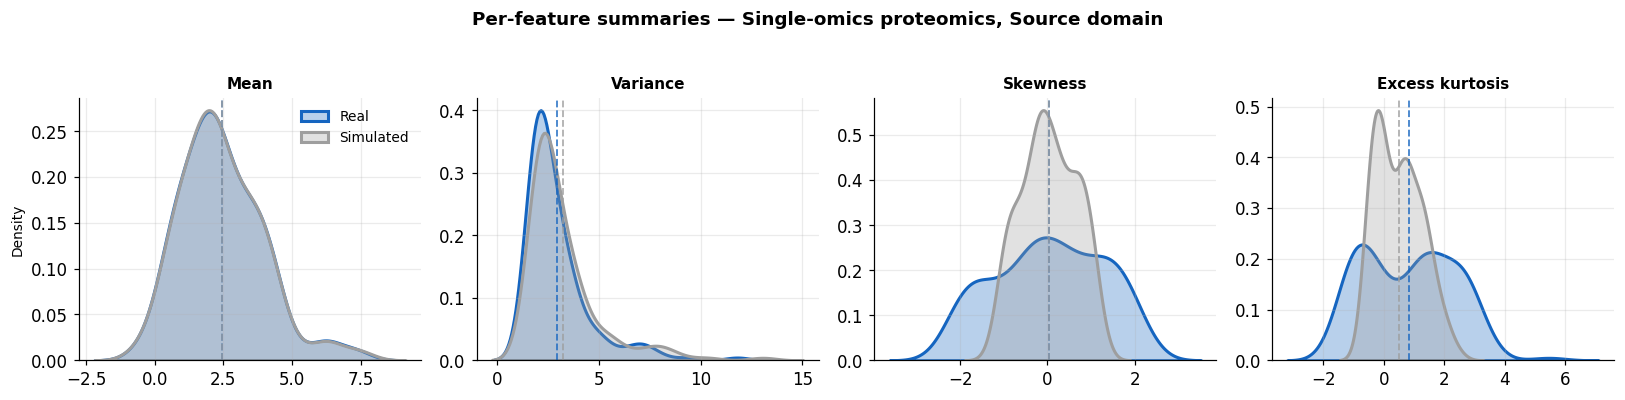

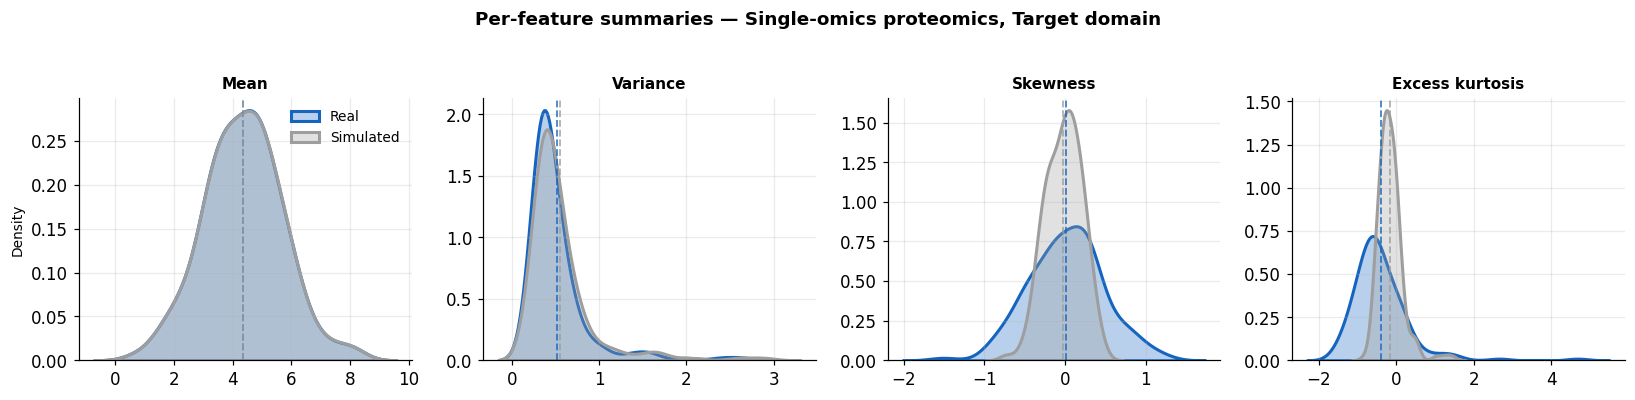

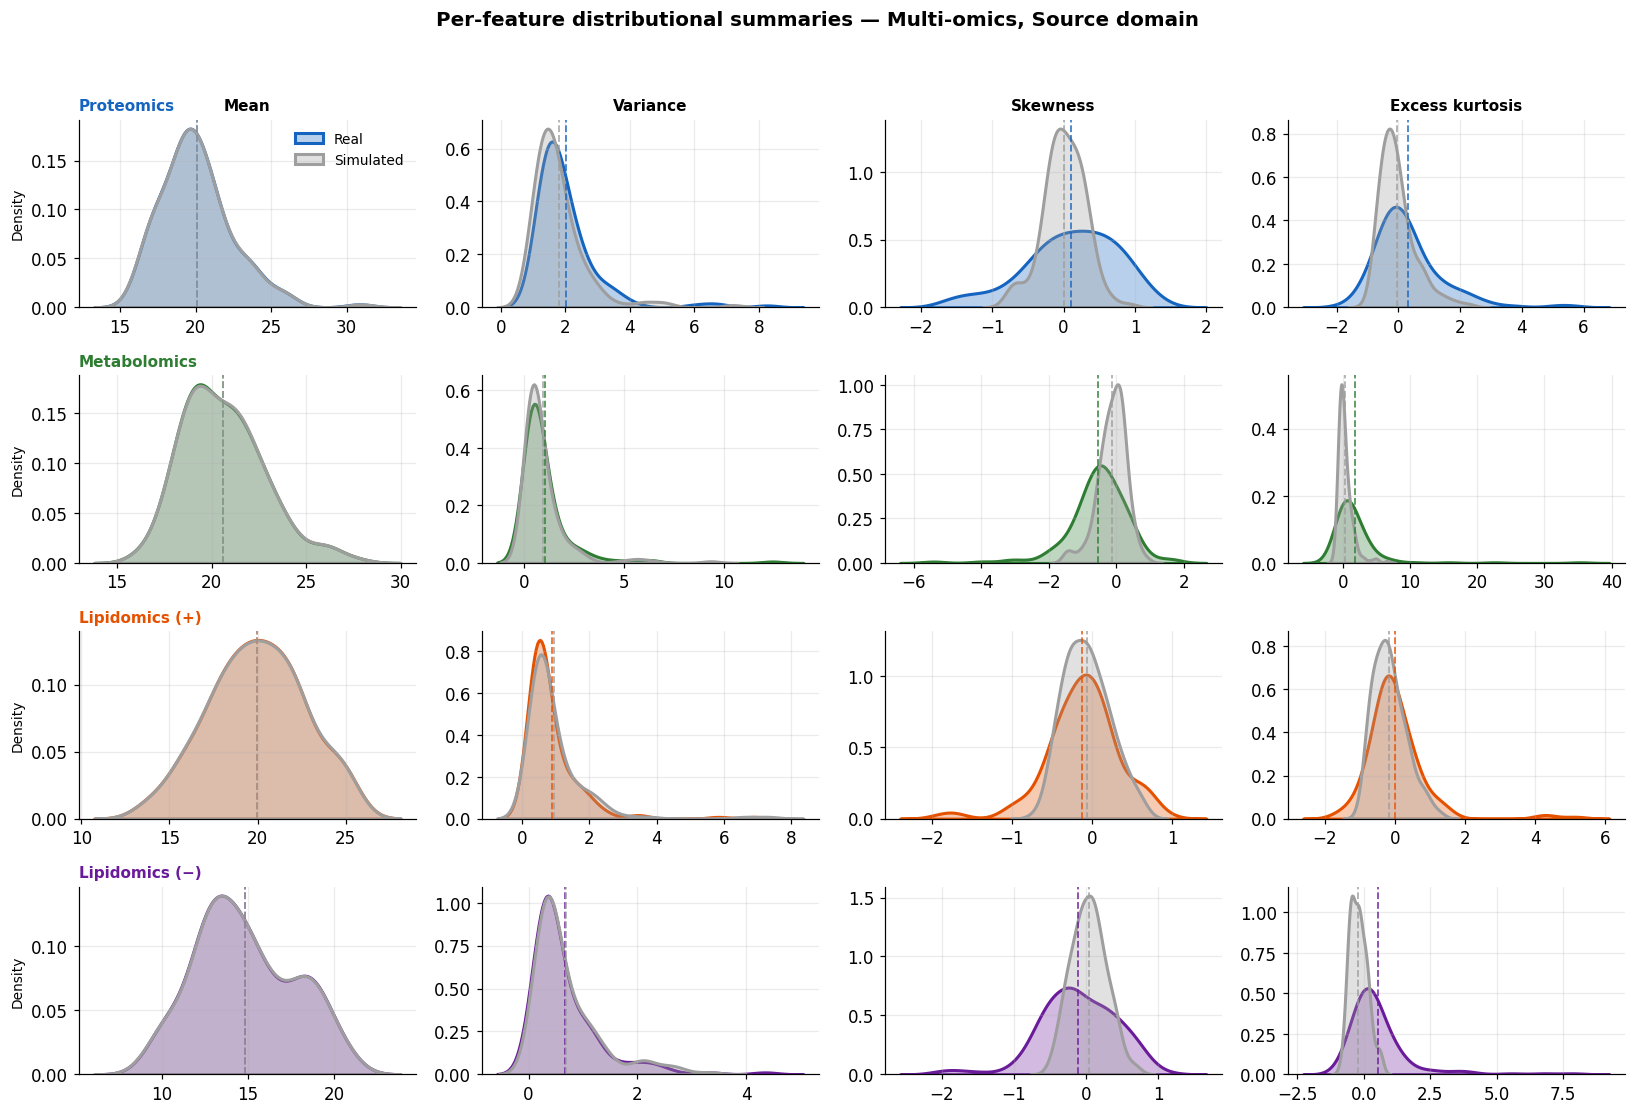

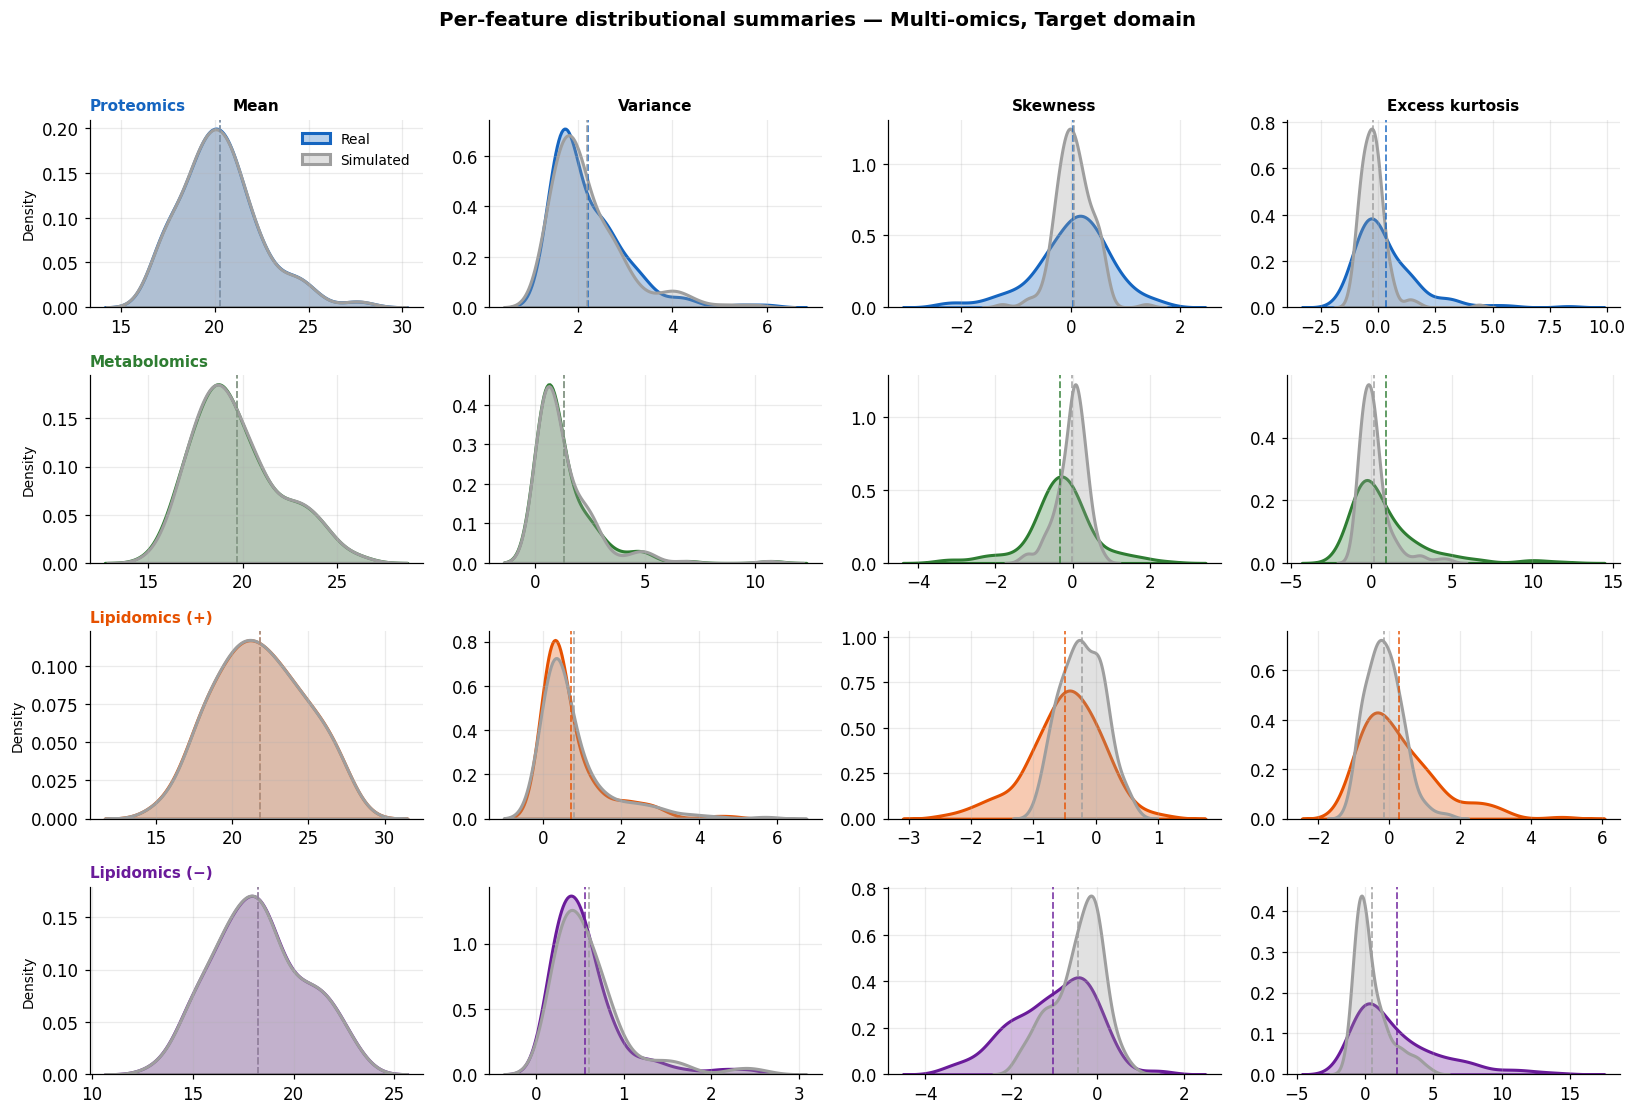

In [8]:
METRICS = ['Mean', 'Variance', 'Skewness', 'Excess kurtosis']

# ── A. Single-omics: proteomics only (1 row × 4 cols) ─────────────────────
for domain in ('Source', 'Target'):
    fig, axes = plt.subplots(1, len(METRICS), figsize=(15, 3.5))
    fig.suptitle(
        f'Per-feature summaries — Single-omics proteomics, {domain} domain',
        fontsize=12, fontweight='bold', y=1.03)

    col_color = COLORS['prot']
    rs, ss = feat_cache[('prot_single', domain)]
    for col, metric in enumerate(METRICS):
        ax = axes[col]
        rv, sv = rs[metric], ss[metric]
        sns.kdeplot(rv, ax=ax, color=col_color, lw=2,
                    fill=True, alpha=0.30, label='Real')
        sns.kdeplot(sv, ax=ax, color=SYN_COLOR, lw=2,
                    fill=True, alpha=0.30, label='Simulated')
        ax.axvline(rv.mean(), color=col_color, lw=1.2, ls='--', alpha=0.8)
        ax.axvline(sv.mean(), color=SYN_COLOR,  lw=1.2, ls='--', alpha=0.8)
        ax.set_title(metric, fontsize=10, fontweight='bold')
        ax.set_ylabel('Density' if col == 0 else '', fontsize=9)
        ax.set_xlabel('')
        if col == 0:
            ax.legend(frameon=False, fontsize=9)

    plt.tight_layout()
    plt.savefig(f'data/fidelity_feature_summaries_singleomics_{domain.lower()}.pdf',
                bbox_inches='tight')
    plt.show()

# ── B. Multi-omics: all 4 layers (4 rows × 4 cols) ────────────────────────
for domain in ('Source', 'Target'):
    fig, axes = plt.subplots(len(OMICS), len(METRICS), figsize=(15, 10))
    fig.suptitle(
        f'Per-feature distributional summaries — Multi-omics, {domain} domain',
        fontsize=13, fontweight='bold', y=1.01)

    for row, omic in enumerate(OMICS):
        rs, ss = feat_cache[(omic, domain)]
        col_color = COLORS[omic]
        for col, metric in enumerate(METRICS):
            ax = axes[row, col]
            rv, sv = rs[metric], ss[metric]
            sns.kdeplot(rv, ax=ax, color=col_color, lw=2,
                        fill=True, alpha=0.30, label='Real')
            sns.kdeplot(sv, ax=ax, color=SYN_COLOR, lw=2,
                        fill=True, alpha=0.30, label='Simulated')
            ax.axvline(rv.mean(), color=col_color, lw=1.2, ls='--', alpha=0.8)
            ax.axvline(sv.mean(), color=SYN_COLOR,  lw=1.2, ls='--', alpha=0.8)

            # Metric name: centered above each column (first row only)
            if row == 0:
                ax.set_title(metric, fontsize=10, fontweight='bold', loc='center')

            # Omic name: top-left title of the first-column panel.
            # Using loc='left' keeps it in the title area (above the axes),
            # so it never overlaps the y-axis "Density" label.
            if col == 0:
                ax.set_title(LABELS[omic], fontsize=10, fontweight='bold',
                             color=col_color, loc='left')
                ax.set_ylabel('Density', fontsize=9)
            else:
                ax.set_ylabel('')

            ax.set_xlabel('')
            if row == 0 and col == 0:
                ax.legend(frameon=False, fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig(f'data/fidelity_feature_summaries_{domain.lower()}.pdf',
                bbox_inches='tight')
    plt.show()


## 8. Figure: KDE overlays — within-omic pairwise correlations

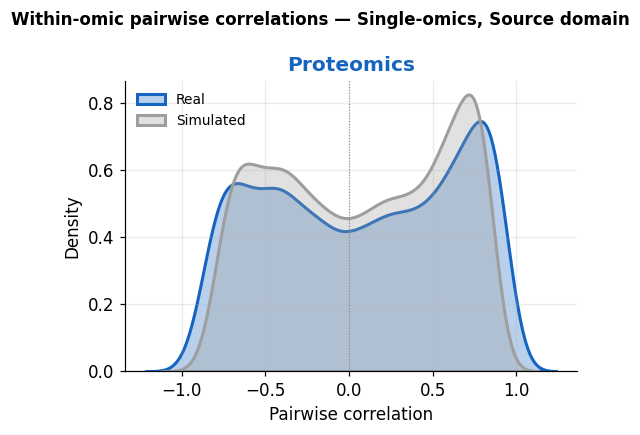

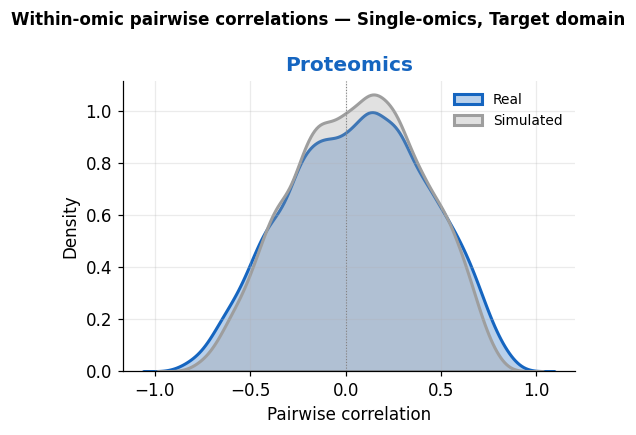

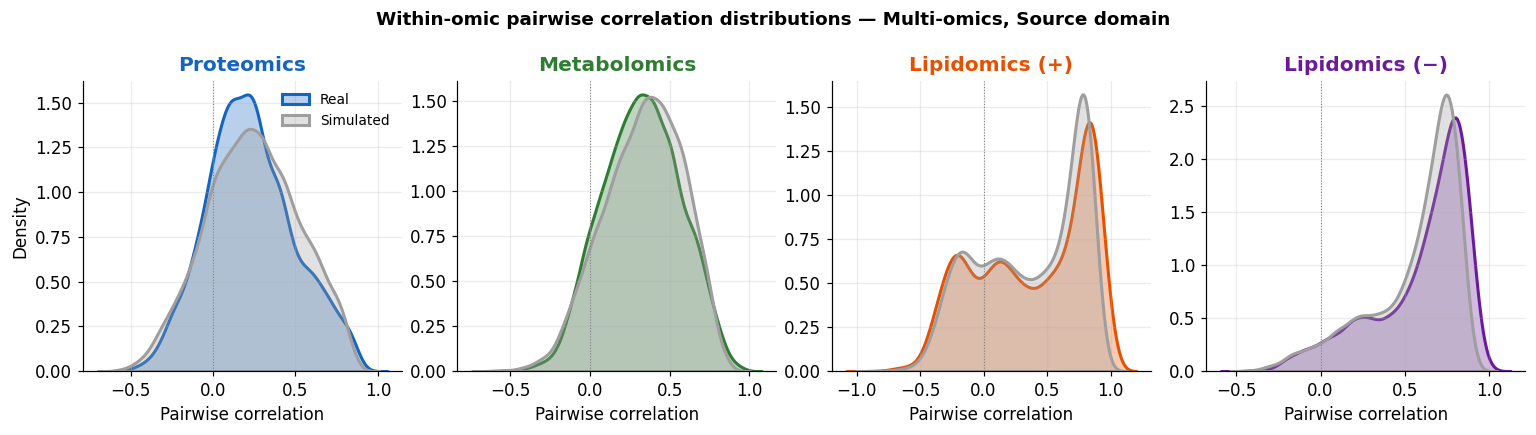

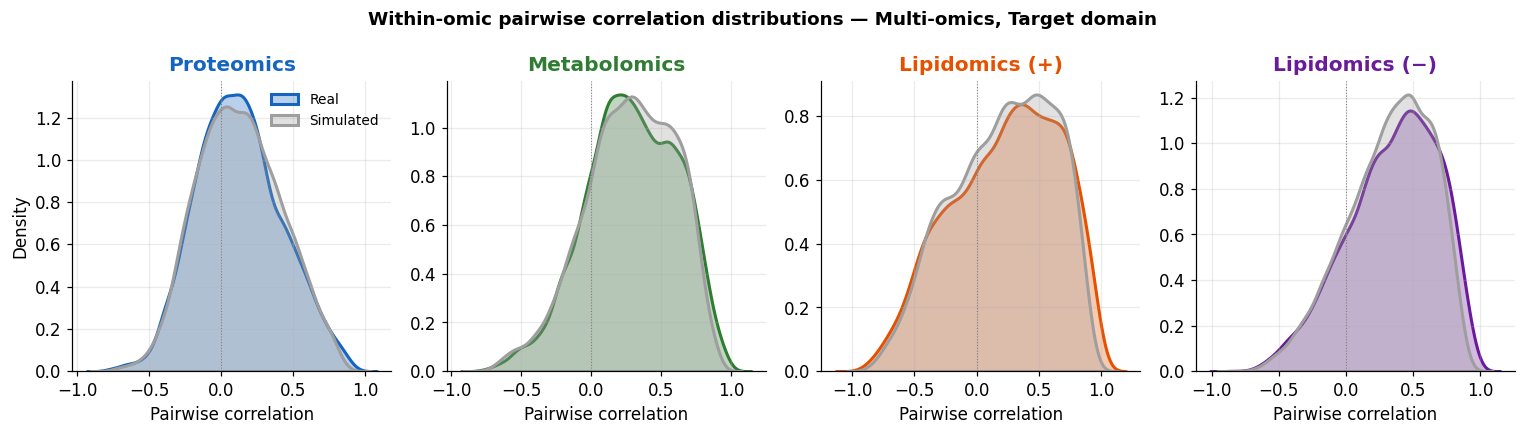

In [9]:
# ── A. Single-omics: proteomics within-omic correlation ───────────────────
for domain in ('Source', 'Target'):
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    fig.suptitle(
        f'Within-omic pairwise correlations — Single-omics, {domain} domain',
        fontsize=11, fontweight='bold')

    col_color = COLORS['prot']
    rt, st = corr_cache[('prot_single', domain)]
    sns.kdeplot(rt, ax=ax, color=col_color, lw=2, fill=True, alpha=0.30, label='Real')
    sns.kdeplot(st, ax=ax, color=SYN_COLOR, lw=2, fill=True, alpha=0.30, label='Simulated')
    ax.axvline(0, color='gray', lw=0.7, ls=':')
    ax.set_title(LABELS['prot'], fontweight='bold', color=col_color)
    ax.set_xlabel('Pairwise correlation')
    ax.set_ylabel('Density')
    ax.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.savefig(f'data/fidelity_within_omic_corr_singleomics_{domain.lower()}.pdf',
                bbox_inches='tight')
    plt.show()

# ── B. Multi-omics: all 4 layers ──────────────────────────────────────────
for domain in ('Source', 'Target'):
    fig, axes = plt.subplots(1, len(OMICS), figsize=(14, 4))
    fig.suptitle(
        f'Within-omic pairwise correlation distributions — Multi-omics, {domain} domain',
        fontsize=12, fontweight='bold')

    for ax, omic in zip(axes, OMICS):
        col_color = COLORS[omic]
        rt, st = corr_cache[(omic, domain)]
        sns.kdeplot(rt, ax=ax, color=col_color, lw=2, fill=True, alpha=0.30, label='Real')
        sns.kdeplot(st, ax=ax, color=SYN_COLOR, lw=2, fill=True, alpha=0.30, label='Simulated')
        ax.axvline(0, color='gray', lw=0.7, ls=':')
        ax.set_title(LABELS[omic], fontweight='bold', color=col_color)
        ax.set_xlabel('Pairwise correlation')
        ax.set_ylabel('Density' if omic == OMICS[0] else '')
        if omic == OMICS[0]:
            ax.legend(frameon=False, fontsize=9)

    plt.tight_layout()
    plt.savefig(f'data/fidelity_within_omic_corr_{domain.lower()}.pdf',
                bbox_inches='tight')
    plt.show()

## 9. Figure: KDE overlays — cross-omic correlations

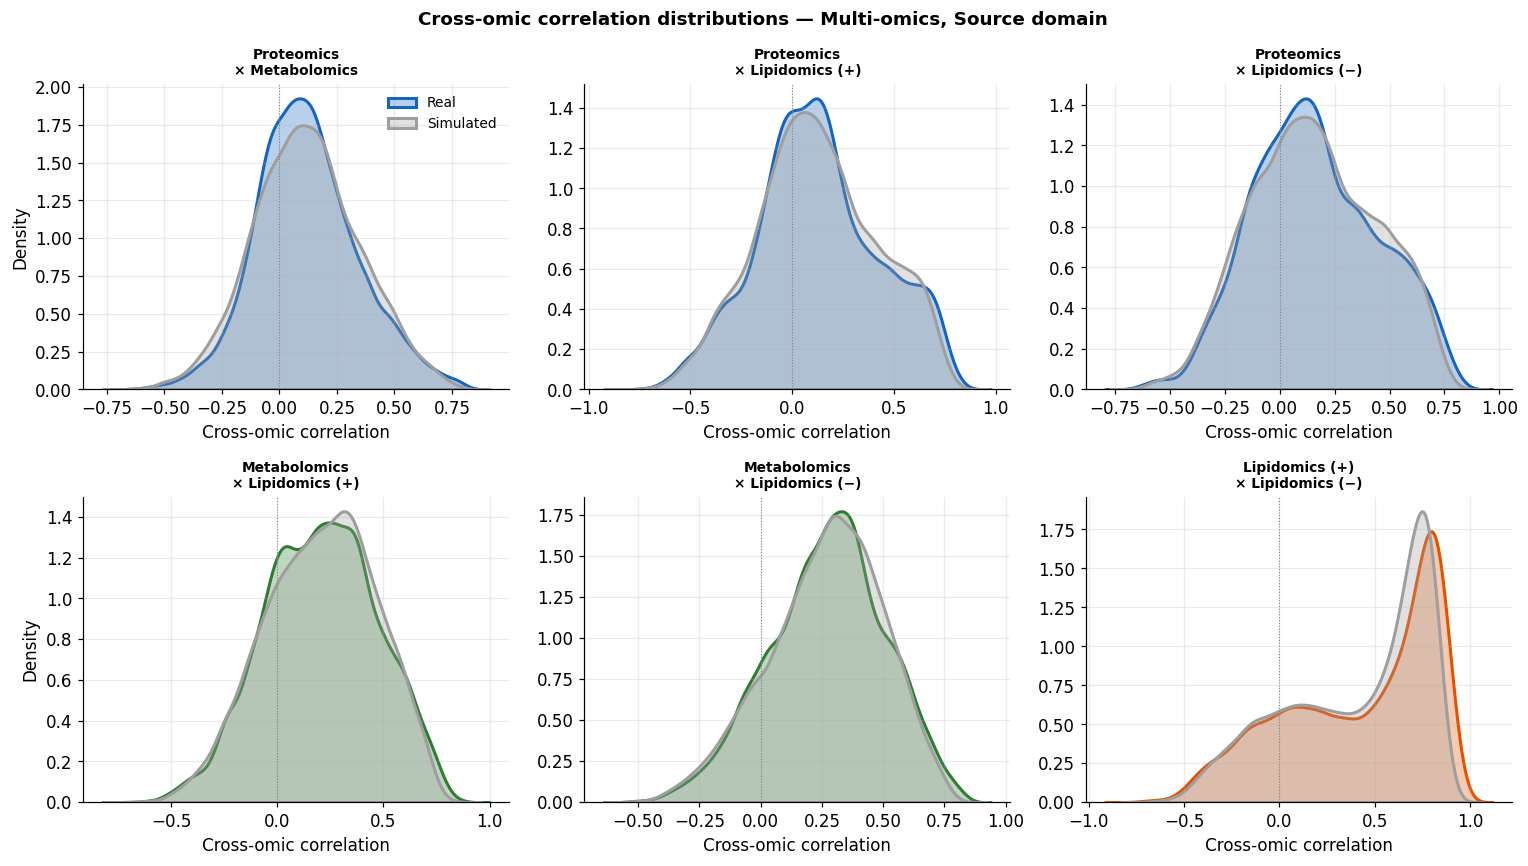

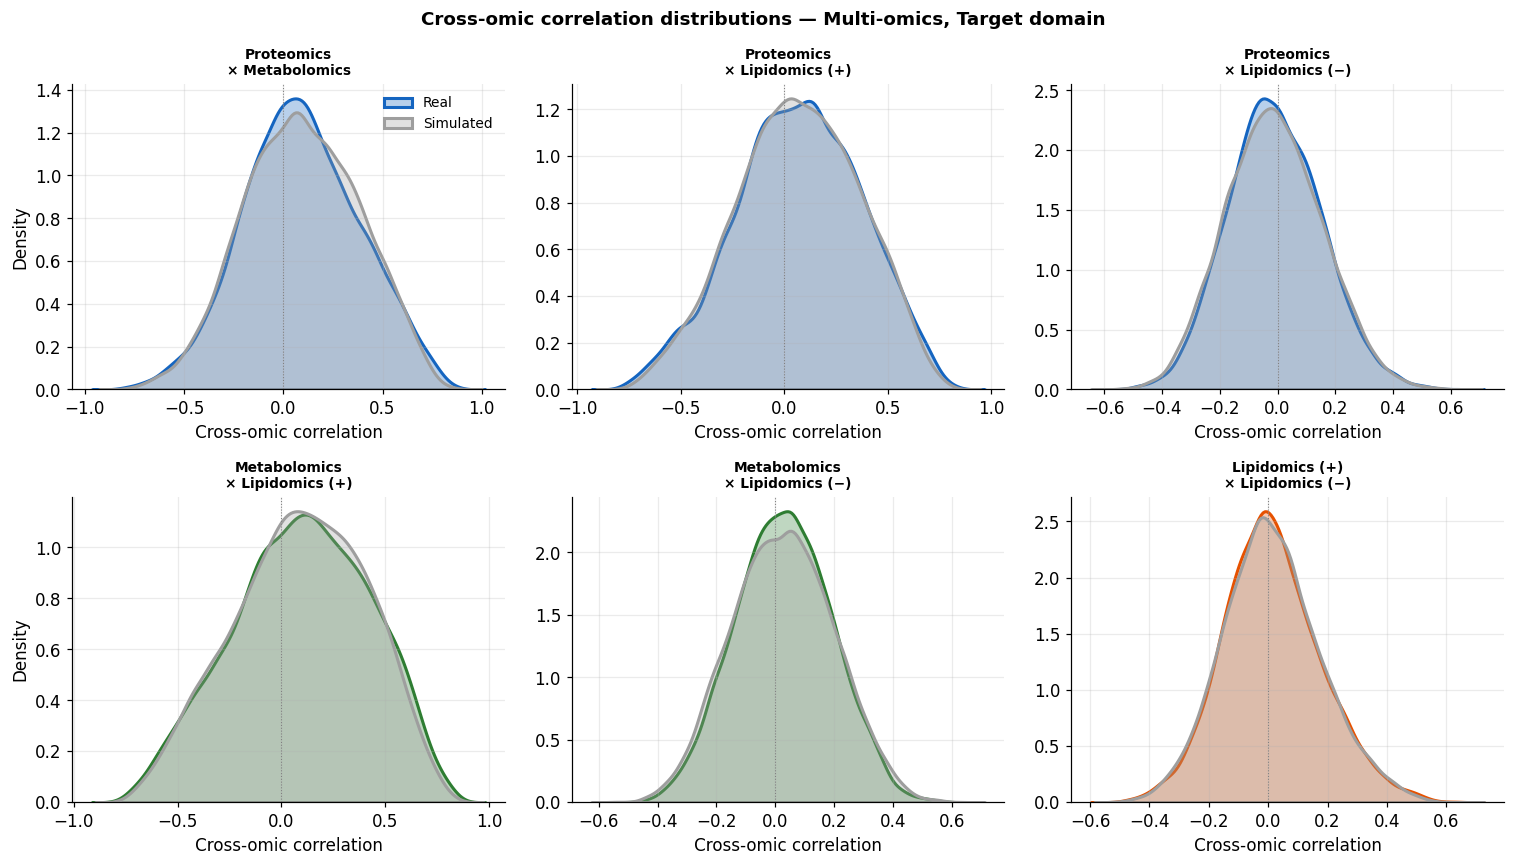

In [10]:
for domain in ('Source', 'Target'):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes_flat = axes.ravel()
    fig.suptitle(
        f'Cross-omic correlation distributions — Multi-omics, {domain} domain',
        fontsize=12, fontweight='bold')

    for idx, (oa, ob) in enumerate(OMIC_PAIRS):
        ax = axes_flat[idx]
        rv, sv = cross_cache[(oa, ob, domain)]
        pair_label = f'{LABELS[oa]}\n× {LABELS[ob]}'
        col_a = COLORS[oa]

        sns.kdeplot(rv, ax=ax, color=col_a, lw=2, fill=True, alpha=0.30, label='Real')
        sns.kdeplot(sv, ax=ax, color=SYN_COLOR, lw=2, fill=True, alpha=0.30, label='Simulated')
        ax.axvline(0, color='gray', lw=0.7, ls=':')
        ax.set_title(pair_label, fontsize=9, fontweight='bold')
        ax.set_xlabel('Cross-omic correlation')
        ax.set_ylabel('Density' if idx % 3 == 0 else '')
        if idx == 0:
            ax.legend(frameon=False, fontsize=9)

    plt.tight_layout()
    plt.savefig(f'data/fidelity_cross_omic_corr_{domain.lower()}.pdf',
                bbox_inches='tight')
    plt.show()

## 10. Summary statistics — mean, median, 95% CI, variance for real vs. synthetic

In [12]:
def dist_summary(arr: np.ndarray, label: str) -> dict:
    """Return mean, median, std, variance, and 95% CI of the mean for a distribution."""
    arr = arr[np.isfinite(arr)]
    n   = len(arr)
    mu  = arr.mean()
    sd  = arr.std(ddof=1)
    se  = sd / np.sqrt(n)
    return {
        'Data':      label,
        'N':         n,
        'Mean':      round(mu, 5),
        'Median':    round(float(np.median(arr)), 5),
        'Std':       round(sd, 5),
        'Variance':  round(arr.var(ddof=1), 5),
        'CI95_low':  round(mu - 1.96 * se, 5),
        'CI95_high': round(mu + 1.96 * se, 5),
    }


rows = []

# ── Per-feature statistics (mean, variance, skewness, excess kurtosis) ─────
for domain in ('Source', 'Target'):
    # Single-omics
    rs, ss = feat_cache[('prot_single', domain)]
    for metric in METRICS:
        for rec in [dist_summary(rs[metric], 'Real'),
                    dist_summary(ss[metric], 'Synthetic')]:
            rows.append({'Study': 'Single-omics', 'Domain': domain,
                         'Layer': LABELS['prot'], 'Category': 'Per-feature stat',
                         'Metric': metric, **rec})

    # Multi-omics
    for omic in OMICS:
        rs, ss = feat_cache[(omic, domain)]
        for metric in METRICS:
            for rec in [dist_summary(rs[metric], 'Real'),
                        dist_summary(ss[metric], 'Synthetic')]:
                rows.append({'Study': 'Multi-omics', 'Domain': domain,
                             'Layer': LABELS[omic], 'Category': 'Per-feature stat',
                             'Metric': metric, **rec})

# ── Within-omic pairwise correlations ──────────────────────────────────────
for domain in ('Source', 'Target'):
    # Single-omics
    rt, st = corr_cache[('prot_single', domain)]
    for rec in [dist_summary(rt, 'Real'), dist_summary(st, 'Synthetic')]:
        rows.append({'Study': 'Single-omics', 'Domain': domain,
                     'Layer': LABELS['prot'], 'Category': 'Within-omic corr',
                     'Metric': 'Pairwise correlation', **rec})

    # Multi-omics
    for omic in OMICS:
        rt, st = corr_cache[(omic, domain)]
        for rec in [dist_summary(rt, 'Real'), dist_summary(st, 'Synthetic')]:
            rows.append({'Study': 'Multi-omics', 'Domain': domain,
                         'Layer': LABELS[omic], 'Category': 'Within-omic corr',
                         'Metric': 'Pairwise correlation', **rec})

# ── Cross-omic pairwise correlations (multi-omics only) ────────────────────
for domain in ('Source', 'Target'):
    for oa, ob in OMIC_PAIRS:
        rv, sv = cross_cache[(oa, ob, domain)]
        pair_label = f'{LABELS[oa]} × {LABELS[ob]}'
        for rec in [dist_summary(rv, 'Real'), dist_summary(sv, 'Synthetic')]:
            rows.append({'Study': 'Multi-omics', 'Domain': domain,
                         'Layer': pair_label, 'Category': 'Cross-omic corr',
                         'Metric': 'Cross-omic correlation', **rec})

summary_df = pd.DataFrame(rows)

COL_ORDER = ['Study', 'Domain', 'Layer', 'Category', 'Metric',
             'Data', 'N', 'Mean', 'Median', 'Std', 'Variance', 'CI95_low', 'CI95_high']
summary_df = summary_df[COL_ORDER]

# ── Display per section ────────────────────────────────────────────────────
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', '{:.5f}'.format)
pd.set_option('display.width', 160)

for study in ('Single-omics', 'Multi-omics'):
    sub = summary_df[summary_df['Study'] == study].drop(columns='Study')
    print(f'{"="*80}')
    print(f'  {study}')
    print(f'{"="*80}')
    for domain in ('Source', 'Target'):
        dsub = sub[sub['Domain'] == domain].drop(columns='Domain')
        print(f'\n--- {domain} domain ---')
        print(dsub.to_string(index=False))
    print()

# Optionally export
summary_df.to_csv('data/fidelity_summary_statistics.csv', index=False)
print('Saved to data/fidelity_summary_statistics.csv')


  Single-omics

--- Source domain ---
     Layer         Category               Metric      Data     N    Mean   Median     Std  Variance  CI95_low  CI95_high
Proteomics Per-feature stat                 Mean      Real   150 2.43026  2.24440 1.49479   2.23439   2.19105    2.66948
Proteomics Per-feature stat                 Mean Synthetic   150 2.43165  2.24363 1.49817   2.24451   2.19189    2.67140
Proteomics Per-feature stat             Variance      Real   150 2.93636  2.32292 1.62409   2.63766   2.67645    3.19626
Proteomics Per-feature stat             Variance Synthetic   150 3.20992  2.50429 1.80489   3.25763   2.92108    3.49876
Proteomics Per-feature stat             Skewness      Real   150 0.04021  0.02579 1.22390   1.49794  -0.15565    0.23608
Proteomics Per-feature stat             Skewness Synthetic   150 0.03310 -0.02008 0.62381   0.38914  -0.06673    0.13293
Proteomics Per-feature stat      Excess kurtosis      Real   150 0.82569  0.99150 1.48675   2.21043   0.58776    1.